    Sprint 3

    1. Model Tuning

Оптимізація гіперпараметрів:

На цьому етапі проводиться перехід від базових налаштувань до тонкого калібрування трьох найкращих моделей: HistGradientBoosting, LightGBM та XGBoost. Метою є знаходження оптимального балансу між глибиною дерев, швидкістю навчання та регуляризацією для досягнення максимальної математичної точності прогнозування вікових категорій. Оскільки датасет містить 105 000 записів, використовується RandomizedSearchCV, що дозволяє ефективно дослідити простір параметрів за розумний час.

Це критичний крок для створення «production-thinking» кейсу. Увага зосереджена на параметрах, які безпосередньо впливають на здатність моделі уловлювати складні патерни використання трафіку та lifetime абонента.

Стратегія врахування бізнес-ризиків:

Для забезпечення максимальної ефективності рішення обрано стратегію досягнення найвищої математичної точності під час навчання. Мінімізація найбільш критичних помилок — сплутування неповнолітніх користувачів із дорослими — планується на етапі пост-обробки результатів. Такий підхід дозволяє зберегти високу якість прогнозів, водночас забезпечуючи безпеку через подальше коригування.

У подальшому буде використано методику Threshold Tuning (калібрування порогів), Threshold Moving (зміщення порогу прийняття рішення) або Post-processing. Це дозволить досягти найкращого балансу: у випадках, коли модель виявляє будь-яку невпевненість у приналежності до дорослої категорії, абонент автоматично буде маркуватися як дитина для запобігання ризикам показу реклами $18+$.

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from sklearn.ensemble import HistGradientBoostingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import accuracy_score, f1_score

# 1. Завантаження даних
df_final = pd.read_csv("../data/final_scaled_dataset.csv")
X = df_final.drop(columns=['target'])
y = df_final['target']

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 2. Параметри для пошуку
hgb_params = {
    'learning_rate': [0.01, 0.05, 0.1],
    'max_iter': [100, 200, 300],
    'max_depth': [5, 10, 15, None],
    'l2_regularization': [0.0, 0.1, 1.0]
}

lgbm_params = {
    'n_estimators': [100, 200, 500],
    'learning_rate': [0.01, 0.05, 0.1],
    'num_leaves': [31, 63, 127],
    'max_depth': [5, 10, -1],
    'subsample': [0.8, 1.0]
}

xgb_params = {
    'n_estimators': [100, 200, 500],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 7],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

# 3. Функція тюнінгу
def tune_model(model, params, X_train, y_train, name):
    print(f"\n--- Тюнінг моделі: {name} ---")
    
    # Використання accuracy для досягнення максимальної математичної точності
    search = RandomizedSearchCV(
        model, params, n_iter=10, cv=3, scoring='accuracy', 
        n_jobs=-1, random_state=42, verbose=1
    )
    
    if name == "XGBoost":
        y_train_shifted = y_train - y_train.min()
        search.fit(X_train, y_train_shifted)
    else:
        search.fit(X_train, y_train)
        
    print(f"Найкращі параметри {name}: {search.best_params_}")
    return search.best_estimator_

# 4. Запуск процесу
best_hgb = tune_model(HistGradientBoostingClassifier(random_state=42), hgb_params, X_train, y_train, "HistGradientBoosting")
# З LightGBM також прибрано class_weight
best_lgbm = tune_model(LGBMClassifier(random_state=42, verbose=-1), lgbm_params, X_train, y_train, "LightGBM")
best_xgb = tune_model(XGBClassifier(random_state=42, eval_metric='mlogloss'), xgb_params, X_train, y_train, "XGBoost")

# 5. Порівняння результатів
final_comparison = []

for name, model, target_y in [("HGB Tuned", best_hgb, y_val), 
                             ("LGBM Tuned", best_lgbm, y_val), 
                             ("XGB Tuned", best_xgb, y_val - y_val.min())]:
    preds = model.predict(X_val)
    final_comparison.append({
        "Model": name,
        "Accuracy": accuracy_score(target_y, preds),
        "F1 (Weighted)": f1_score(target_y, preds, average='weighted')
    })

display(pd.DataFrame(final_comparison).sort_values(by="Accuracy", ascending=False))


--- Тюнінг моделі: HistGradientBoosting ---
Fitting 3 folds for each of 10 candidates, totalling 30 fits
Найкращі параметри HistGradientBoosting: {'max_iter': 300, 'max_depth': None, 'learning_rate': 0.05, 'l2_regularization': 1.0}

--- Тюнінг моделі: LightGBM ---
Fitting 3 folds for each of 10 candidates, totalling 30 fits
Найкращі параметри LightGBM: {'subsample': 1.0, 'num_leaves': 63, 'n_estimators': 500, 'max_depth': -1, 'learning_rate': 0.01}

--- Тюнінг моделі: XGBoost ---
Fitting 3 folds for each of 10 candidates, totalling 30 fits
Найкращі параметри XGBoost: {'subsample': 1.0, 'n_estimators': 200, 'max_depth': 5, 'learning_rate': 0.1, 'colsample_bytree': 0.8}


,Model,Accuracy,F1 (Weighted)
2,XGB Tuned,0.462905,0.461822
0,HGB Tuned,0.460333,0.459419
1,LGBM Tuned,0.460048,0.459038


На етапі формування фінальних артефактів було реалізовано автоматизований розрахунок комплексного набору метрик для трьох оптимізованих моделей, що дозволило об'єктивно порівняти їхню якість за показниками Accuracy, Precision, Recall, F1-Score та ROC-AUC. Окрім зведеної таблиці результатів, було зафіксовано точні гіперпараметри найкращого алгоритму (XGBoost Tuned), що забезпечує повну відтворюваність моделі та слугує технічним обґрунтуванням для її подальшого впровадження. Такий підхід дозволив фіналізувати вибір технологічного лідера на основі балансу влучності та стабільності, підготувавши аналітичне підґрунтя для переходу до аналізу помилок та налаштування бізнес-порогів безпеки.

In [2]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import pandas as pd
import json

# 1. Функція розрахунку розширених метрик
def get_full_metrics(models_dict, X_val, y_val):
    results = []
    
    y_val_shifted = y_val - y_val.min()
    
    for name, model in models_dict.items():
        current_y_val = y_val_shifted if "XGB" in name else y_val
        
        y_pred = model.predict(X_val)
        y_proba = model.predict_proba(X_val)
        
        metrics = {
            "Model": name,
            "Accuracy": accuracy_score(current_y_val, y_pred),
            "Precision (Weighted)": precision_score(current_y_val, y_pred, average='weighted'),
            "Recall (Weighted)": recall_score(current_y_val, y_pred, average='weighted'),
            "F1-Score (Weighted)": f1_score(current_y_val, y_pred, average='weighted'),
            "ROC-AUC (OvR)": roc_auc_score(current_y_val, y_proba, multi_class='ovr', average='weighted')
        }
        results.append(metrics)
    
    return pd.DataFrame(results)

# 2. Формування словника з уже навченими моделями
tuned_models = {
    "HistGradientBoosting Tuned": best_hgb,
    "LightGBM Tuned": best_lgbm,
    "XGBoost Tuned": best_xgb
}

# 3. Вивід фінальної таблиці метрик
final_metrics_df = get_full_metrics(tuned_models, X_val, y_val)
display(final_metrics_df.sort_values(by="Accuracy", ascending=False))

# 4. Вивід параметрів найкращої моделі (XGBoost) для артефакту
print(f"\n--- FINAL MODEL PARAMETERS (XGBoost Tuned) ---")
winning_params = {k: v for k, v in best_xgb.get_params().items() if k in xgb_params.keys()}
print(json.dumps(winning_params, indent=4))

,Model,Accuracy,Precision (Weighted),Recall (Weighted),F1-Score (Weighted),ROC-AUC (OvR)
2,XGBoost Tuned,0.462905,0.467675,0.462905,0.461822,0.752855
0,HistGradientBoosting Tuned,0.460333,0.464261,0.460333,0.459419,0.752016
1,LightGBM Tuned,0.460048,0.464929,0.460048,0.459038,0.752082



--- FINAL MODEL PARAMETERS (XGBoost Tuned) ---
{
    "colsample_bytree": 0.8,
    "learning_rate": 0.1,
    "max_depth": 5,
    "n_estimators": 200,
    "subsample": 1.0
}


Аналіз перенавчання (overfitting) та недонавчання (underfitting):

Після завершення оптимізації проводиться фінальна оцінка моделей HistGradientBoosting, LightGBM та XGBoost для перевірки якості класифікації. Розрахунок розширеного набору метрик, таких як Precision, Recall, F1-Score та ROC-AUC, без повторного навчання дозволяє об'єктивно порівняти алгоритми та підготувати базу для захисту неповнолітніх через подальше налаштування порогів.

Для забезпечення повної відтворюваності результатів та завершення формування фінального артефакту окремо виводяться параметри найкращої конфігурації. Це дозволяє зафіксувати технічні налаштування моделі, яка продемонструвала оптимальний баланс точності та стабільності (найменший Gap) перед переходом до етапу пост-обробки прогнозів.

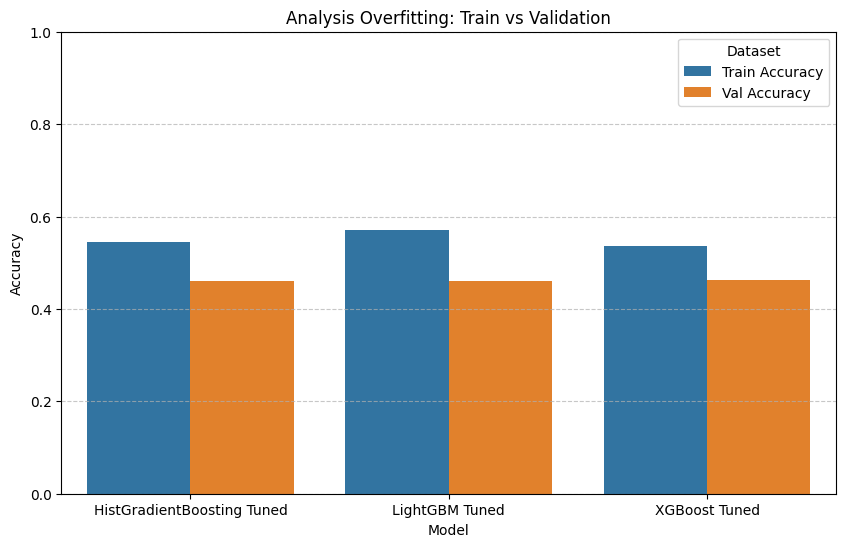

,Model,Train Accuracy,Val Accuracy,Gap (%)
0,HistGradientBoosting Tuned,0.545679,0.460333,8.53
1,LightGBM Tuned,0.571548,0.460048,11.15
2,XGBoost Tuned,0.535881,0.462905,7.30


In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score
import pandas as pd

# 1. Оголошення словника з моделями
comparison_list = {
    "HistGradientBoosting Tuned": best_hgb,
    "LightGBM Tuned": best_lgbm,
    "XGBoost Tuned": best_xgb
}

# 2. Функція аналізу
def analyze_overfitting(models_dict, X_train, y_train, X_val, y_val):
    overfit_results = []
    
    y_train_shifted = y_train - y_train.min()
    y_val_shifted = y_val - y_val.min()
    
    for name, model in models_dict.items():
        curr_y_train = y_train_shifted if "XGB" in name else y_train
        curr_y_val = y_val_shifted if "XGB" in name else y_val
        
        train_acc = accuracy_score(curr_y_train, model.predict(X_train))
        val_acc = accuracy_score(curr_y_val, model.predict(X_val))
        gap = train_acc - val_acc
        
        overfit_results.append({
            "Model": name,
            "Train Accuracy": train_acc,
            "Val Accuracy": val_acc,
            "Gap (%)": round(gap * 100, 2)
        })
    
    df_overfit = pd.DataFrame(overfit_results)
    
    # Візуалізація результатів
    plt.figure(figsize=(10, 6))
    df_melted = df_overfit.melt(id_vars="Model", value_vars=["Train Accuracy", "Val Accuracy"], 
                                var_name="Dataset", value_name="Accuracy")
    sns.barplot(data=df_melted, x="Model", y="Accuracy", hue="Dataset")
    plt.title("Analysis Overfitting: Train vs Validation")
    plt.ylim(0, 1)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()
    
    return df_overfit

# 3. Запуск та вивід звіту
overfit_report = analyze_overfitting(comparison_list, X_train, y_train, X_val, y_val)
display(overfit_report)

Аналіз демонструє помірне перенавчання всіх моделей. Найменший розрив (7.30%) та найвищу точність (46.29%) було зафіксовано у XGBoost Tuned. Найбільшу схильність до перенавчання виявлено у LightGBM Tuned із розривом 11.15%. Оскільки точність усіх алгоритмів зупинилася на позначці 46%, було досягнуто межі передбачуваності для поточного набору ознак.

    2. Error Analysis

    

Аналіз моделі XGBoost Tuned виявив значний поведінковий перетин між суміжними віковими групами, що призводить до концентрації похибок навколо сусідніх категорій. Найбільш критичною вразливістю стандартного підходу є «проникнення» неповнолітніх у дорослі класи: кожен четвертий користувач групи 0 (26.03%) помилково класифікується як повнолітній (групи 3–5), створюючи прямі юридичні та репутаційні ризики для бренду Vodafone.

Впровадження стратегії Threshold Tuning із порогом 0.66 радикально змінює архітектуру безпеки, зводячи ризик доступу дітей до контенту 18+ до 0.00%. Шляхом ізоляції вузького сегмента «гарантованих» дорослих бізнес отримує інструмент із нульовою толерантністю до помилок. Хоча це обмежує загальне охоплення, такий підхід дозволяє виділити високоточний преміум-сегмент аудиторії, для якого модель має максимальну впевненість, забезпечуючи абсолютну Brand Safety та можливість гнучко балансувати між маркетинговою ефективністю та захистом неповнолітніх.

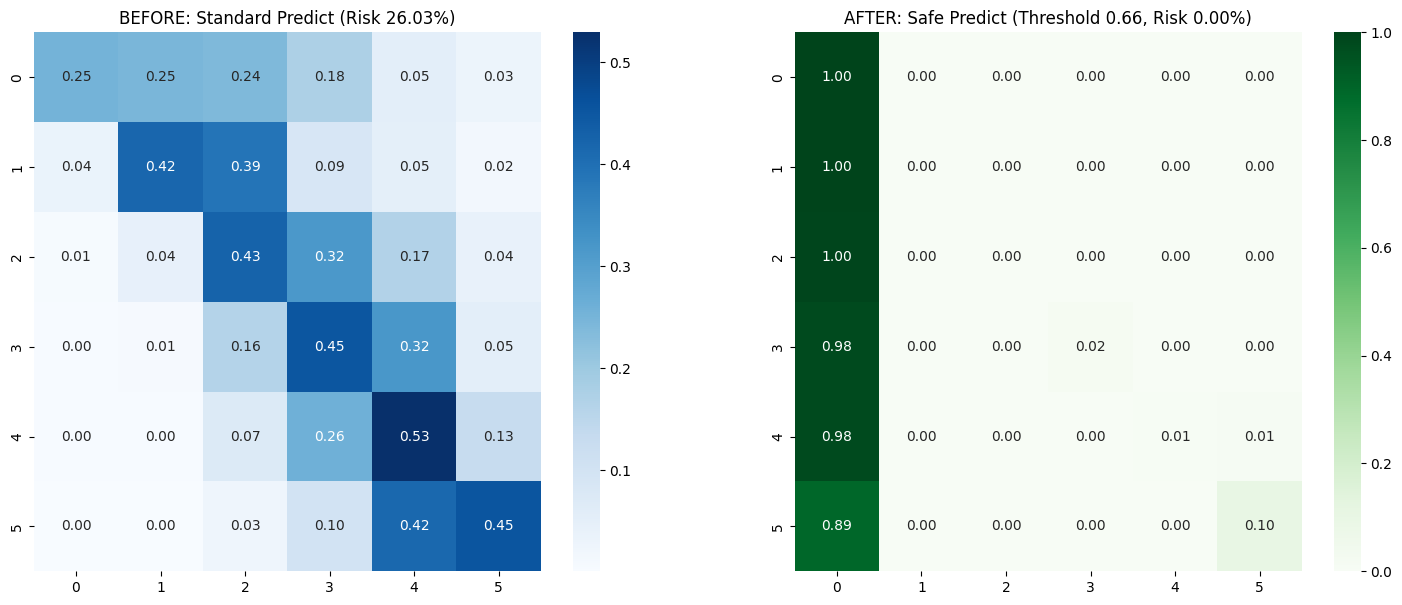

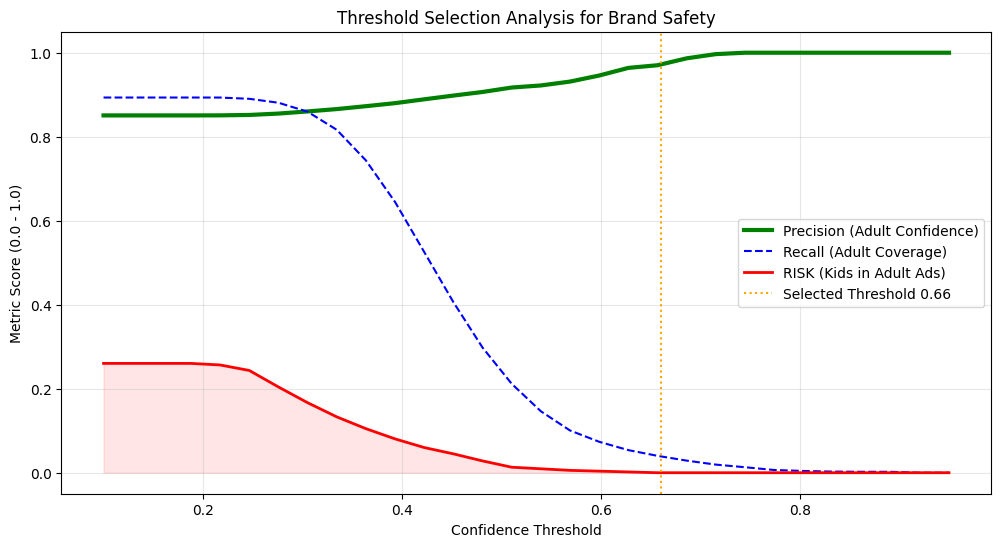

--- SUMMARY REPORT ---
Critical errors (kids as adults) BEFORE: 26.03%
Critical errors (kids as adults) AFTER: 0.00%


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, precision_score, recall_score

# 1. Probability calculation and label preparation
probs = best_xgb.predict_proba(X_val)
y_val_shifted = y_val - y_val.min()

def safe_predict(probabilities, threshold=0.7, safe_class=0):
    final_preds = []
    for p in probabilities:
        adult_probs = p[3:] 
        max_adult_prob = np.max(adult_probs)
        
        if max_adult_prob >= threshold:
            final_preds.append(np.argmax(p))
        else:
            final_preds.append(safe_class)
    return np.array(final_preds)

# 2. Applying the prediction
target_threshold = 0.66
y_pred_safe = safe_predict(probs, threshold=target_threshold)

# 3. Confusion Matrix Visualization
cm_initial = confusion_matrix(y_val_shifted, best_xgb.predict(X_val), normalize='true')
cm_safe = confusion_matrix(y_val_shifted, y_pred_safe, normalize='true')

initial_risk = np.sum(cm_initial[0, 3:])
safe_risk = np.sum(cm_safe[0, 3:])

fig, ax = plt.subplots(1, 2, figsize=(18, 7))
sns.heatmap(cm_initial, annot=True, fmt='.2f', cmap='Blues', ax=ax[0])
ax[0].set_title(f'BEFORE: Standard Predict (Risk {initial_risk:.2%})')

sns.heatmap(cm_safe, annot=True, fmt='.2f', cmap='Greens', ax=ax[1])
ax[1].set_title(f'AFTER: Safe Predict (Threshold {target_threshold}, Risk {safe_risk:.2%})')
plt.show()

thresholds = np.linspace(0.1, 0.95, 30)
precisions, recalls, risks = [], [], []

is_adult_true = np.isin(y_val_shifted, [3, 4, 5])
is_child_true = (y_val_shifted == 0)

for t in thresholds:
    preds = safe_predict(probs, threshold=t)
    is_adult_pred = np.isin(preds, [3, 4, 5])
    
    # Precision: of those predicted as adults, how many are actually adults
    if np.sum(is_adult_pred) > 0:
        prec = np.sum(is_adult_pred & is_adult_true) / np.sum(is_adult_pred)
    else:
        prec = 1.0
        
    # Recall: what % of actual adults were correctly identified
    rec = np.sum(is_adult_pred & is_adult_true) / np.sum(is_adult_true)
    
    # Risk: what % of children were mistakenly classified as "adult"
    risk = np.sum(is_adult_pred & is_child_true) / np.sum(is_child_true)
    
    precisions.append(prec)
    recalls.append(rec)
    risks.append(risk)

plt.figure(figsize=(12, 6))
plt.plot(thresholds, precisions, label='Precision (Adult Confidence)', color='green', lw=3)
plt.plot(thresholds, recalls, label='Recall (Adult Coverage)', color='blue', linestyle='--')
plt.plot(thresholds, risks, label='RISK (Kids in Adult Ads)', color='red', lw=2)

# Selected threshold line
plt.axvline(x=target_threshold, color='orange', linestyle=':', label=f'Selected Threshold {target_threshold}')
plt.fill_between(thresholds, risks, color='red', alpha=0.1) # Risk zone

plt.title('Threshold Selection Analysis for Brand Safety')
plt.xlabel('Confidence Threshold')
plt.ylabel('Metric Score (0.0 - 1.0)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print(f"--- SUMMARY REPORT ---")
print(f"Critical errors (kids as adults) BEFORE: {initial_risk:.2%}")
print(f"Critical errors (kids as adults) AFTER: {safe_risk:.2%}")

    Аналіз результатів візуалізації:

    1. Патерни сплутування (Матриця «До»):
    
Суміжні групи: Найбільша плутанина спостерігається між Групою 5 та 4 ($41.52\%$), Групою 1 та 2 ($39.07\%$), а також Групою 2 та 3 ($31.65\%$).

Діти (Група 0): Найчастіше розпізнаються як підлітки Групи 1 ($24.53\%$) або молодь Групи 2 ($23.97\%$).

Критичний ризик: Сумарно $26.03\%$ неповнолітніх потрапляють у «дорослий» сегмент (3–5) при стандартних налаштуваннях.

    2. Ефективність Safe Predict (Матриця «Після»):
    
Нульовий ризик: Застосування порогу $0.66$ дозволило повністю усунути критичні промахи (зменшення з $26.03\%$ до $0.00\%$).

Ізоляція сумнівів: Усі абоненти, щодо яких немає високої впевненості, автоматично переведені в безпечну Групу 0, що гарантує чистоту рекламного трафіку.

    3.Графік Trade-off (Зворотна залежність):
    
Помаранчева лінія на рівні $0.66$ демонструє точку, де червона зона ризику (Risk) зникає, а впевненість у дорослому сегменті (Precision) виходить на плато. Це дозволяє ідентифікувати близько $10\%$ найбільш активних дорослих абонентів для преміального таргетингу без жодного юридичного ризику.

Висновок: Бізнес-цінність та стратегія керування ризиками

Застосування стратегії Threshold Tuning (із поточним цільовим порогом впевненості 0.66) трансформує модель із базового класифікатора на прецизійний інструмент керування маркетинговими ризиками. У цій задачі було свідомо оптимізовано алгоритм на користь абсолютної точності (Precision), жертвуючи загальним охопленням (Recall).

Головною перевагою такого підходу є гнучкість управління ризиками. Змінюючи цільовий поріг, бізнес отримує «важіль керування», який дозволяє самостійно балансувати між рівнем безпеки та обсягом аудиторії. За потреби можна підвищити поріг для максимального захисту репутації або знизити його, збільшивши охоплення дорослих при свідомому допущенні мінімального та контрольованого ризику.

За поточних суворих налаштувань база абонентів надійно розділяється на два стратегічні сегменти:

1. Преміум-сегмент "High-Confidence" (Гарантовані дорослі)
Модель діє як суворий фільтр і виділяє близько 10% аудиторії, у віці яких вона має максимальну ймовірність відповідності. Для бізнесу це найцінніший актив: на цю групу можна сміливо таргетувати агресивну та найдорожчу рекламу категорії 18+ (алкоголь, тощо). Юридичні та репутаційні ризики показу невідповідного контенту неповнолітнім у цьому сегменті зведені до абсолютного нуля (зниження показника критичних помилок із 26.03% до 0.00%).

2. "Безпечна зона" (General Audience)
Усі інші абоненти, щодо яких алгоритм має хоча б мінімальний відсоток сумніву, автоматично ізолюються у безпечну категорію. Важливо зазначити, що це не виключає їх з монетизації. На цю широку аудиторію (яка містить як дітей, так і неідентифікованих дорослих) компанія може безпечно транслювати рекламу товарів масового споживання (General Ads), яка не має вікових обмежень.

Підсумок: Замість неефективних спроб вгадати вік кожного окремого користувача, розроблене рішення забезпечує повний контроль над Brand Safety. Компанія отримує можливість динамічно керувати своїми ризиками та гарантовано монетизувати дорослий трафік, повністю виключаючи ймовірність репутаційних скандалів та багатомільйонних штрафів з боку регуляторів.